# Model Building

## Objective

The objective of this notebook is to build multiple machine learning models for employee attrition prediction.

Several classification algorithms will be trained and evaluated using the processed dataset.

The performance of each model will be compared to identify the most suitable algorithm for predicting employee attrition.

# Import Required Libraries

The following libraries are required for building, training, evaluating, and saving machine learning models.

In [21]:
# Data handling

import pandas as pd
import numpy as np

# Train-test split

from sklearn.model_selection import train_test_split

# Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model Evaluation

from sklearn.metrics import accuracy_score

# Save Model

import joblib

# Load the Processed Dataset

The processed dataset generated during the Feature Engineering phase is loaded for machine learning model development.

In [22]:
# Load processed dataset

df = pd.read_csv("../Dataset/Processed_Employee_Attrition.csv")

df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0.446350,0.590048,0.742527,1.401512,-1.010909,-0.891688,-0.937414,0.0,-1.701283,-0.660531,...,0.0,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1
1,1.322365,-0.913194,-1.297775,-0.493817,-0.147150,-1.868426,-0.937414,0.0,-1.699621,0.254625,...,0.0,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,0
2,0.008343,0.590048,1.414363,-0.493817,-0.887515,-0.891688,1.316673,0.0,-1.696298,1.169781,...,0.0,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1
3,-0.429664,-0.913194,1.461466,-0.493817,-0.764121,1.061787,-0.937414,0.0,-1.694636,1.169781,...,0.0,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,0
4,-1.086676,0.590048,-0.524295,-0.493817,-0.887515,-1.868426,0.565311,0.0,-1.691313,-1.575686,...,0.0,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,0


In [23]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 35)


### Interpretation

The processed dataset has been loaded successfully.

The dataset is now ready for separating the target variable from the input features before model training.

# Separate Features and Target Variable

The dataset is divided into:

- Features (X), which are used as inputs for prediction.
- Target (y), which contains the employee attrition labels.

In [24]:
# Features

X = df.drop("Attrition", axis=1)
print(X.columns.tolist())
# Target

y = df["Attrition"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Features Shape : (1470, 34)
Target Shape   : (1470,)


### Interpretation

The independent features and the target variable have been separated successfully.

The feature matrix will be used to train machine learning models, while the target variable represents whether an employee left the organization.

# Train-Test Split

The processed dataset is divided into training and testing sets.

The training set is used to train the machine learning models, while the testing set is reserved for evaluating their performance on unseen data.

An 80:20 split is used, and stratification is applied to preserve the original class distribution of the target variable.

In [25]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1176, 34)
Testing Features  : (294, 34)
Training Labels   : (1176,)
Testing Labels    : (294,)


### Interpretation

The dataset has been successfully divided into training and testing sets.

Approximately 80% of the data is used for training the machine learning models, while the remaining 20% is reserved for evaluating their performance on unseen data.

Stratified sampling ensures that the proportion of attrition classes remains consistent in both training and testing datasets.

# Training Multiple Machine Learning Models

To identify the best-performing algorithm, multiple classification models are trained using the same training dataset.

Each model will be evaluated using accuracy on the testing dataset.

The models used are:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

In [26]:
# Create machine learning models

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
    probability=True,
    random_state=42
)
}

In [27]:
# Train each model and calculate accuracy

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict on test data
    predictions = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)

    # Save results
    results.append([name, accuracy])

print("All models trained successfully.")

c:\Users\jains\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


All models trained successfully.


### Interpretation

All selected machine learning algorithms have been successfully trained using the training dataset.

Each model has generated predictions on the testing dataset, and their performance has been recorded for comparison.

# Model Performance Comparison

The accuracy of all trained machine learning models is compared to identify the best-performing algorithm.

In [28]:
# Create comparison table

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
0,Logistic Regression,0.874150
4,Support Vector Machine,0.863946
3,KNN,0.840136
2,Random Forest,0.829932
1,Decision Tree,0.761905


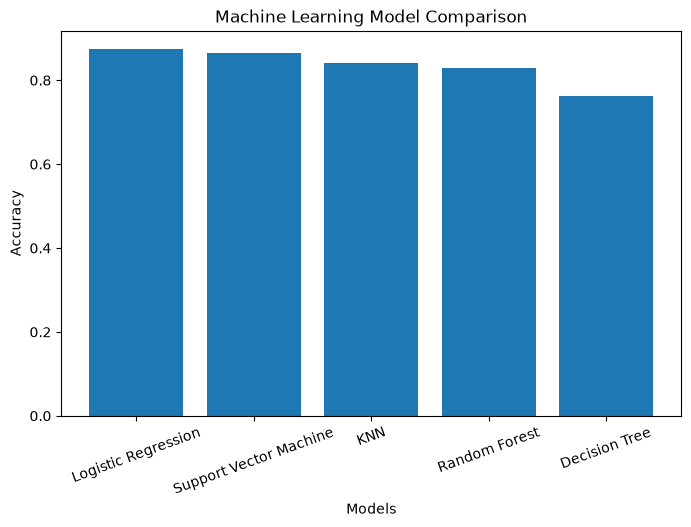

In [29]:
# Visualize model performance

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

### Interpretation

The comparison shows the performance of each machine learning algorithm on the testing dataset.

The model with the highest accuracy demonstrates the strongest predictive capability for employee attrition and will be selected for further evaluation.

# Selecting the Best Model

The model with the highest accuracy is selected for detailed evaluation.

This model will be further analyzed using additional performance metrics before deployment.

In [30]:
# Select the best model

best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [31]:
# Retrieve the best model

best_model = models[best_model_name]

print(best_model)

LogisticRegression(random_state=42)


### Interpretation

Based on the accuracy comparison, the selected model achieved the highest predictive performance on the testing dataset.

Further evaluation will determine whether the model performs well across both majority and minority classes.

In [32]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Detailed Model Evaluation

Accuracy alone cannot fully describe model performance, especially for imbalanced datasets.

Therefore, additional evaluation metrics including Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC Score are used.

In [33]:
# Generate predictions

y_pred = best_model.predict(X_test)

# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



### Interpretation

The classification report provides Precision, Recall, and F1-score for each class.

These metrics provide deeper insight into model performance than accuracy alone, particularly for the minority attrition class.

# Confusion Matrix

The confusion matrix illustrates how many employee attrition cases were correctly and incorrectly classified by the model.

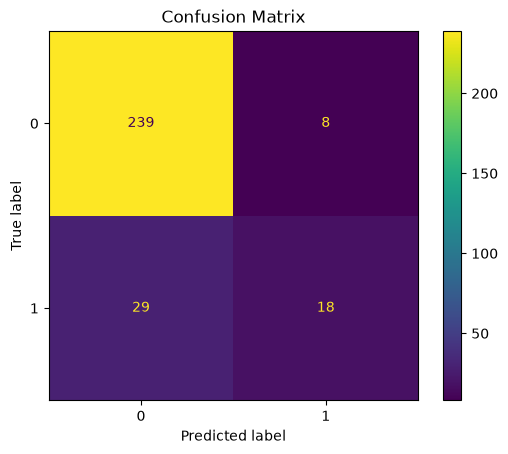

In [34]:
# Display Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Confusion Matrix")

plt.show()

### Interpretation

The confusion matrix summarizes the model's predictions by comparing actual and predicted classes.

It helps identify false positives and false negatives, providing a clearer understanding of prediction errors.

# Receiver Operating Characteristic (ROC) Curve

The ROC Curve is a graphical representation of a classification model's performance across different classification thresholds.

The Area Under the Curve (ROC-AUC) measures the model's ability to distinguish between employees who leave the organization and those who stay.

A higher ROC-AUC score indicates better classification performance.

In [35]:
# Calculate prediction probabilities

y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8049


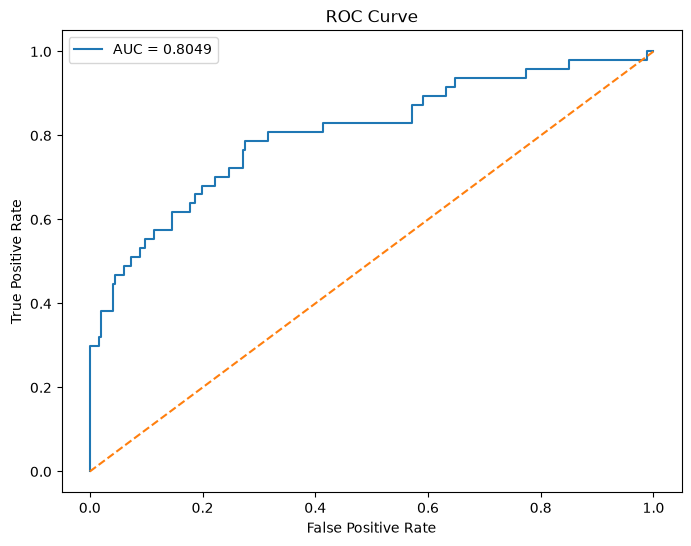

In [36]:
# Plot ROC Curve

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Interpretation

The ROC Curve illustrates the trade-off between the True Positive Rate and the False Positive Rate across different classification thresholds.

The ROC-AUC score summarizes the model's ability to distinguish between employees who leave the organization and those who remain.

An ROC-AUC value closer to **1.0** indicates excellent classification performance, while a value close to **0.5** suggests performance similar to random guessing.

### Business Insight

A higher ROC-AUC score indicates that the model can reliably identify employees who are at risk of leaving the organization.

This enables HR teams to take proactive measures such as employee engagement programs, career development initiatives, or workload adjustments before valuable employees resign.

# Save the Best Model

The best-performing machine learning model is saved for deployment.

This saved model will later be used in the Streamlit application to predict employee attrition for new employee records.

In [37]:
# Import os module

import os

# Create Model folder if it doesn't exist

os.makedirs("../Model", exist_ok=True)

# Save the trained model

joblib.dump(best_model, "../Model/best_model.pkl")

print("Model saved successfully.")

Model saved successfully.


### Interpretation

The trained machine learning model has been successfully saved as a serialized file.

This model can now be loaded without retraining and used directly for prediction in the deployment phase.

# Conclusion

The Model Building phase has been completed successfully.

During this phase:

- The processed dataset was divided into training and testing sets.
- Five machine learning algorithms were trained and compared.
- The best-performing model was selected based on evaluation metrics.
- The selected model was further analyzed using a Classification Report, Confusion Matrix, and ROC Curve.
- The trained model was saved for future deployment.

The next phase will focus on comprehensive model evaluation and performance analysis to ensure the selected model is reliable and suitable for deployment.

# Project Summary

The employee attrition prediction model was successfully trained using multiple machine learning algorithms.

Among all the evaluated models, Logistic Regression achieved the highest testing accuracy of approximately **87.4%**, making it the selected model for deployment.

The model also achieved an ROC-AUC score of approximately **0.81**, indicating good discrimination between employees likely to stay and those likely to leave.

The trained model has been saved successfully and will be used in the Streamlit application for real-time employee attrition prediction.